In [11]:
import os, json
import numpy as np
import SimpleITK as sitk
from typing import Dict, Sequence, Union, Tuple, Optional
import Data.IO as dio

from scipy.ndimage.measurements import label
import matplotlib.pyplot as plt
from Volume.Edition import drawSphere
from Evaluation.Evaluation import getRadius
from Volume.Selection import ConnectedComponents2Spheres_1

## Helpers

In [12]:
def save_json(data: tuple, path: str, indent: int = 4):
    if not("json" == path.split("/")[-1].split(".")[-1]):
        path = path + ".json"
    with open(path, "w") as f:
        json.dump(data, f, indent=indent)

def plot_pr_curve(
    precisions, recalls, category='Person', label=None, color=None, ax=None):
    if ax is None:
        plt.figure(figsize=(10,8))
        ax = plt.gca()

    if color is None:
        color = '#1f77b4'
    ax.scatter(recalls, precisions, label=label, s=20, color=color)
    ax.set_xlabel('recall')
    ax.set_ylabel('precision')
    ax.set_title('Precision-Recall curve for {}'.format(category))
    ax.set_xlim([0.0,1.3])
    ax.set_ylim([0.0,1.2])
    return ax

def calc_precision_recall(true_pos, false_pos, false_neg):
    try:
        precision = true_pos/(true_pos + false_pos)
    except ZeroDivisionError:
        precision = 0.0
    try:
        recall = true_pos/(true_pos + false_neg)
    except ZeroDivisionError:
        recall = 0.0
    return precision, recall

def iou(inputs, targets, smooth = 1e-8):
    intersection = (inputs * targets).sum()
    iou = intersection / (inputs.sum() + targets.sum() - intersection.sum() + smooth)
    #print(f"\tiou = {iou} = {intersection}/ {(inputs.sum() + targets.sum() - intersection.sum() + smooth)}")
    return iou

## Segementation to detection

In [ ]:
seg_file_path = "/path/to/0Work/5Fold-Validation/Fold1_again/Predictions/200_epochs/P0189.nii.gz",
out_dir = "/path/to/0Work/5Fold-Validation/Fold1_again/Predictions/200_epochs/labels"

In [ ]:
def seg2det(file: str,
            out_dir: str,
            instance_seg = False,
            min_size: float = 0,
            min_vol: float = 0, 
            min_diameter: float = 0):
    """
        'stuff_classes' : these are classes which are interpreted semantically = labels[background=0, other = 1] 
        'things_classes' : these are classes which are interpreted as INSTANCES [background = 0, CC1 = 1, CC2 = 2]
        `min_size`: minimum size in mm of objects in the isotropic axis (default 0)
        `min_vol`: minimum volume of instances in pixels (default 0)
    """
    case_id = os.path.basename(file).split(".")[0]
    label_path = os.path.join(out_dir, f"{case_id}.json")
    if False: #os.path.isfile(label_path):
        print(f"Found existing case {case_id} -> skipping")
        return
    if not os.path.exists(out_dir):
        os.makedirs(out_dir)
    print(f"Processing {case_id}")
        
    # load volume
    seg, v2m = dio.read_nii_from_file(file)
    # Optional = thresholding
#    threshold = 0.1
#    seg[seg < threshold] = 0
#    seg[seg >= threshold] = 1

    ########################### Preprocessing #########################
    labels = skme.label(seg)
    ncc_labels = labels.max()
    print(f"\t{ncc_labels} CC in total")
    for i in range(1, ncc_labels + 1):
        instance_mask = seg.copy()
        instance_mask[instance_mask == i]
        diameter = 2 * ConnectedComponents2Spheres(instance_mask, v2m)[0][-1]
        if diameter < min_diameter :
            seg [instance_mask == 1] = 0
            print(f"\t- Remove CC with {round(diameter, 3)} mm in diameter")
    
    final_mapping = {}
    if not instance_seg:
        #################### Prepare semantic segmentation ####################
        final_mapping[1] = 0
        dio.save_nii_to_file(os.path.join(out_dir, f"{case_id}_semantic.nii.gz",), seg, v2m)
        print(f"\t- Saved as semantic segmentation")
        
    else:
        #################### Prepare instance segmentation ####################
        if seg.max() > 0:
            seg = skme.label(seg)
            ncc_labels = seg.max()
            print(f"\t{ncc_labels} CC in total")
            for i in range(1, ncc_labels + 1):
                final_mapping[i] = i - 1
            dio.save_nii_to_file(os.path.join(out_dir, f"{case_id}_instance.nii.gz",), seg, v2m)
            print(f"\t- Saved as instance segmentation")
    save_json(data = {"instances": final_mapping}, path = label_path)
    return seg

#seg2det(seg_file_path,
#        out_dir,
#        instance_seg = True,
#        min_diameter = 1  )

## Evaluation

### Tests

In [ ]:
pred, v2m = dio.read_nii_from_file("/path/to/0Work/5Fold-Validation/Fold1/Predictions/200_epochs/P0189.nii.gz",)
gt, _ = dio.read_nii_from_file("/path/to/0Work/5Fold-Validation/Fold1/Predictions/200_epochs/P0189.nii.gz",)
assert pred.shape == gt.shape, "different shape values !!"

In [ ]:
# get CC
cc_pred = ConnectedComponents2Spheres(pred, v2m)
gt_cc = ConnectedComponents2Spheres(gt, v2m)

print(cc_pred)
# Save prediction and GT to json files
data = {}
for id, cc in enumerate (cc_pred):
    data[id] = {"center" : list(cc[:-2]), "radius" : cc[-2], "confidence": cc[-1]}
    save_json(data = data, path = "/path/to/0Work/P0189_prediction.json")
data = {}
for id, cc in enumerate (gt_cc):
    data[id] = {"center" : list(cc[:-2]), "radius" : cc[-2], "confidence": cc[-1]}
    save_json(data = data, path = "/path/to/0Work/P0189_truth.json")

In [ ]:
# Read Spheres from files
with open("/path/to/0Work/P0189_prediction.json", "r") as f:
    predictions = json.load(f)
spheres_pred = np.empty((0,5))
for key in predictions:
    spheres_pred = np.vstack((spheres_pred, np.hstack((predictions[key]["center"], predictions[key]["radius"], predictions[key]["confidence"]))))
print(spheres_pred)

with open("/path/to/0Work/P0189_truth.json", "r") as f:
    gt = json.load(f)
spheres_gt = np.empty((0,5))
for key in gt:
    spheres_gt = np.vstack((spheres_gt, np.hstack((gt[key]["center"], gt[key]["radius"], gt[key]["confidence"]))))
print(spheres_gt)

### Generate labels.json from Predictions.nii.gz

In [89]:
predicitions_files = [
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0001.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0017.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0024.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0041.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0048.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0059.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0067.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0081.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0086.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0101.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0107.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0119.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0122.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0007.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0020.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0027.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0042.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0051.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0060.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0068.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0083.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0087.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0105.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0109.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0120.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0129.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0002.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0014.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0021.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0039.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0047.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0057.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0066.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0078.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0085.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0097.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0106.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0118.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0121.nii.gz",
                        "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0130.nii.gz",
]
def save_label_file(path):
    print(path)
    # load prediction
    pred, v2m = dio.read_nii_from_file(path)
    # CC to spheres
    spheres = ConnectedComponents2Spheres_1(pred, v2m, 0.05)
    print(spheres)
    data = {}
    for id, cc in enumerate (spheres):
        data[id] = {"center" : list(cc[:-2]), "radius" : cc[-2], "confidence": cc[-1]}
        out_file = os.path.join("/".join(path.split("/")[:-1]), "Labels", path.split("/")[-1].split('.')[0]+".json")
        save_json(data = data, path = out_file)

for path in predicitions_files:
    save_label_file(path)


/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs/P0001.nii.gz
1
[[-18.49542384  -1.20410807  -1.09177075   4.23277803   1.        ]]


### Compute CM

In [10]:
def get_CM(pred_spheres, truth_spheres, v2m, iou_thr = 0.1, confidence_thr= 0.05, vol=None, verbose=False):
    FP, TP, FN = 0, 0, 0
    confidence_tp, confidence_fp = [], []
    precision, recall = 0,0
    ################ confidence_thr #################
    spheres = pred_spheres.copy()
    for idx, sphere in enumerate(pred_spheres):
        if sphere[-1] < confidence_thr:
            spheres = np.delete(pred_spheres, idx, axis=0)
    pred_spheres=spheres

    ncc_detections = pred_spheres.shape[0]
    ncc_truth = truth_spheres.shape[0]
    
    if ncc_detections == 0:
        return {'TP': 0, 'FP': 0, 'FN': ncc_truth, 'confidence_tp': confidence_tp, 'confidence_fp': confidence_fp, 'precision': precision, 'recall': recall}
    if ncc_truth == 0:
        return {'TP': 0, 'FP': ncc_detections, 'FN': 0,  'confidence_tp': confidence_tp, 'confidence_fp': confidence_fp, 'precision': precision, 'recall': recall}
    
    pred = np.zeros((560, 560, 300))
    gt = pred.copy()

    # Draw spheres
    for s in pred_spheres:
        drawSphere(pred, v2m, c = s[:3], r = s[3], val = s[-1])
    for s in truth_spheres:
        drawSphere(gt, v2m, c = s[:3], r = s[3], val = 1)

    #dio.save_nii_to_file("/path/to/gt.nii.gz", gt, v2m)

    cc_detections, a = label(pred)
    cc_gt, b = label(gt)
    if verbose:
        print(f"\t {a} detections vs {b}  aneurysms")


    # loop over detections CC
    for i in range(1, ncc_detections + 1):
        mask_pred = cc_detections.copy()
        mask_pred[cc_detections == i] = 1
        mask_pred[cc_detections != i] = 0

        #dio.save_nii_to_file(f"/path/to/pred_{i}.nii.gz", mask_pred, v2m)
        if mask_pred.sum() > 0:
            confidence_score = pred[mask_pred == 1].max()
            if verbose:
                print(f"\tconfidence = {confidence_score}")
            ious = []
            # loop over ground truth CC
            for j in range(1, ncc_truth + 1):
                mask_gt = cc_gt.copy()
                mask_gt[cc_gt == j] = 1
                mask_gt[cc_gt != j] = 0
                # compute IoU
                iou_score = iou(inputs = mask_pred, targets = mask_gt)
                if verbose:
                    print(f"\tDetection {i} vs GT {j} : iou = {iou_score}")
                if iou_score > iou_thr :
                    ious.append(iou_score)

            if len(ious) == 1:
                TP += 1
                print(f"{round(confidence_score*100, 4)} TP ")
                confidence_tp.append(confidence_score)
            elif len(ious) > 1:
                print("multiple intersections !")
                FP += (len(ious) - 1)
                confidence_fp.extend([confidence_score]*len(ious))
            else:
                FP += 1
                print(f"{round(confidence_score*100, 4)} FP ")
                confidence_fp.append(confidence_score)
    FN = b - TP
    precision, recall = calc_precision_recall(TP, FP, FN)
    return {'TP': TP, 'FP': FP, 'FN':  FN, 'confidence_tp': confidence_tp, 'confidence_fp': confidence_fp, 'precision': precision, 'recall': recall}

### Patient-wise Confusion Matrix

In [13]:

labels_dir = "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs"
patients = [os.path.join(labels_dir, f) for f in sorted(os.listdir(labels_dir)) if ".nii.gz" in f]

def get_precision_and_recall(patients, iou=0.1, confidence_thr=0.05):
    FPs, TPs, FNs = 0, 0, 0
    Precisions, recalls = [], []
    for patient in patients:
        pat_name = patient.split("/")[-1].split(".")[0]
        if True: #"P0101" in pat_name:
            print(f"{pat_name}", end=" : ")
            pred, v2m = dio.read_nii_from_file(patient)
            label_file = os.path.join(labels_dir, "Labels", f"{pat_name}.json")
            with open(label_file, "r") as f:
                predictions = json.load(f)
            pred_spheres = np.empty((0,5))
            for key in predictions:
                pred_spheres = np.vstack((pred_spheres, np.hstack((predictions[key]["center"], predictions[key]["radius"], predictions[key]["confidence"]))))
            truth_spheres = dio.points_to_spheres(dio.read_points_from_csv(os.path.join("/path/to/Data/CHRU/", pat_name, "F.csv")))

            CM = get_CM(pred_spheres, truth_spheres, v2m=v2m, iou_thr = iou, confidence_thr=confidence_thr, vol=pred, verbose=False)
            TPs += CM['TP']
            FPs += CM['FP']
            FNs += CM['FN']
            Precisions.append(CM['precision'])
            recalls.append(CM['recall'])

#            print(f"\t{CM['TP']} TP + {CM['FP']} FP + {CM['FN']} FN")

    print(f"{TPs} TPs + {FPs} FPs + {FNs} FNs")
#    print(f"Snesitivity/Recall : {round(sum(recalls)/len(recalls), 3)}")
#    print(f"Precision : {round(sum(Precisions)/len(Precisions), 3)}")
    return sum(Precisions)/len(Precisions), sum(recalls)/len(recalls)
get_precision_and_recall(patients, iou=0.5, confidence_thr=0.01)

P0001 : 100.0 TP 
P0002 : 100.0 TP 
P0007 : 32.0535 FP 
100.0 FP 
P0014 : 100.0 FP 
100.0 TP 
P0017 : 100.0 TP 
99.8309 FP 
P0020 : 90.148 FP 
P0021 : 100.0 TP 
100.0 FP 
99.3135 FP 
P0024 : P0027 : 99.8993 FP 
99.9014 FP 
15.9598 FP 
P0039 : 99.9791 FP 
P0041 : 99.6534 FP 
99.9998 FP 
97.9677 FP 
P0042 : 100.0 TP 
P0047 : P0048 : 100.0 FP 
P0051 : 56.2029 FP 
100.0 FP 
99.6942 FP 
P0057 : 100.0 TP 
P0059 : 100.0 TP 
P0060 : 100.0 TP 
P0066 : 100.0 FP 
99.5392 TP 
P0067 : 100.0 TP 
P0068 : 100.0 TP 
99.9273 FP 
P0078 : 71.1876 FP 
P0081 : 100.0 TP 
P0083 : 86.8197 FP 
100.0 TP 
P0085 : 100.0 TP 
P0086 : 99.8043 FP 
100.0 TP 
P0087 : 100.0 TP 
5.7844 FP 
P0097 : 99.8603 FP 
P0101 : 30.276 FP 
99.9838 FP 
P0105 : 99.3929 FP 
P0106 : 100.0 FP 
P0107 : 100.0 TP 
100.0 TP 
12.6214 FP 
94.0558 FP 
P0109 : 100.0 TP 
P0118 : 100.0 TP 
P0119 : 100.0 TP 
P0120 : 99.7621 FP 
98.7626 FP 
99.8562 FP 
P0121 : 100.0 TP 
100.0 FP 
P0122 : 100.0 TP 
100.0 TP 
P0129 : 100.0 TP 
P0130 : 100.0 TP 
27 TPs 

(0.4958333333333334, 0.4454166666666667)

### Element-wise Detection Matrix

In [75]:
labels_dir = "/path/to/0Work/Experiments/Networks/UNet/Predictions/200_epochs"
patients = [os.path.join(labels_dir, f) for f in sorted(os.listdir(labels_dir)) if ".nii.gz" in f]
detections = []
# loop over patients
acc_TP, acc_FP, acc_FN = 0, 0, 0
precision, recall = 0, 0

for patient in patients:
    detection = []
    pat_name = patient.split("/")[-1].split(".")[0]
    pred, v2m = dio.read_nii_from_file(patient)
    label_file = os.path.join(labels_dir, "Labels", f"{pat_name}.json")
    with open(label_file, "r") as f:
        predictions = json.load(f)
    pred_spheres = np.empty((0,5))
    for key in predictions:
        pred_spheres = np.vstack((pred_spheres, np.hstack((predictions[key]["center"], predictions[key]["radius"], predictions[key]["confidence"]))))
    truth_spheres = dio.points_to_spheres(dio.read_points_from_csv(os.path.join("/path/to/Data/CHRU/", pat_name, "F.csv")))

    
    # loop over detections
    
    ncc_detections = pred_spheres.shape[0]
    ncc_truth = truth_spheres.shape[0]
    
    if ncc_detections == 0:
        acc_FN += ncc_truth
    if ncc_truth == 0:
        return {'TP': 0, 'FP': ncc_detections, 'FN': 0,  'confidence_tp': confidence_tp, 'confidence_fp': confidence_fp, 'precision': precision, 'recall': recall}
    
    pred = np.zeros((560, 560, 300))
    gt = pred.copy()

    # Draw spheres
    for s in pred_spheres:
        drawSphere(pred, v2m, c = s[:3], r = s[3], val = s[-1])
    for s in truth_spheres:
        drawSphere(gt, v2m, c = s[:3], r = s[3], val = 1)

    #dio.save_nii_to_file("/path/to/gt.nii.gz", gt, v2m)

    cc_detections, a = label(pred)
    cc_gt, b = label(gt)
    if verbose:
        print(f"\t {a} detections vs {b}  aneurysms")


    # loop over detections CC
    for i in range(1, ncc_detections + 1):
        mask_pred = cc_detections.copy()
        mask_pred[cc_detections == i] = 1
        mask_pred[cc_detections != i] = 0

        #dio.save_nii_to_file(f"/path/to/pred_{i}.nii.gz", mask_pred, v2m)
        if mask_pred.sum() > 0:
            confidence_score = pred[mask_pred == 1].max()
            if verbose:
                print(f"\tconfidence = {confidence_score}")
            ious = []
            # loop over ground truth CC
            for j in range(1, ncc_truth + 1):
                mask_gt = cc_gt.copy()
                mask_gt[cc_gt == j] = 1
                mask_gt[cc_gt != j] = 0
                # compute IoU
                iou_score = iou(inputs = mask_pred, targets = mask_gt)
                if verbose:
                    print(f"\tDetection {i} vs GT {j} : iou = {iou_score}")
                if iou_score > iou_thr :
                    ious.append(iou_score)

            if len(ious) == 1:
                TP += 1
                confidence_tp.append(confidence_score)
            elif len(ious) > 1:
                print("multiple intersections !")
                FP += (len(ious) - 1)
                confidence_fp.extend([confidence_score]*len(ious))
            else:
                FP += 1
                confidence_fp.append(confidence_score)
    
    
    
    
    
    
    
    
    CM = get_CM(pred_spheres, truth_spheres, v2m=v2m, iou_thr = 0.1, vol=pred, verbose=False)
    detection += CM['confidence_tp']
    print(detection)
#    print(CM)
    break

        
    detections.append(detection)

[1.0]


### Plot Precision vs Recall curve

In [3]:
precision_scores = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0.975, 0.9756, 0.976190476, 0.976744186, 0.954545455, 0.933333333, 0.913043478, 0.914893617, 0.916666667, 0.918367347, 0.92, 0.901960784, 0.884615385, 0.867924528, 0.886792453, 0.854545455, 0.839285714, 0.824561404, 0.810344828, 0.796610169, 0.783333333, 0.770491803, 0.774193548] + [ 0, 0]
recall_scores = [0.015384615, 0.030769231, 0.046153846, 0.061538462, 0.076923077, 0.092307692, 0.107692308, 0.123076923, 0.138461538, 0.153846154, 0.169230769, 0.184615385, 0.2, 0.215384615, 0.230769231, 0.246153846, 0.261538462, 0.276923077, 0.292307692, 0.307692308, 0.323076923, 0.338461538, 0.353846154, 0.369230769, 0.384615385, 0.4, 0.415384615, 0.430769231, 0.446153846, 0.461538462, 0.476923077, 0.492307692, 0.507692308, 0.523076923, 0.538461538, 0.553846154, 0.569230769, 0.584615385, 0.6, 0.6, 0.615384615, 0.630769231, 0.646153846, 0.646153846, 0.646153846, 0.646153846, 0.661538462, 0.676923077, 0.692307692, 0.707692308, 0.707692308, 0.707692308, 0.707692308, 0.723076923, 0.723076923, 0.723076923, 0.723076923, 0.723076923, 0.723076923, 0.723076923, 0.723076923, 0.738461538]+ [0.738461538, 1]

In [4]:
i=len(recall_scores) - 2
interpolated_precision_scores = precision_scores
while i >= 0:
    if interpolated_precision_scores[i+1] > interpolated_precision_scores[i]:
        interpolated_precision_scores[i] = interpolated_precision_scores[i+1]
    i=i-1


Text(0, 0.5, 'Precision')

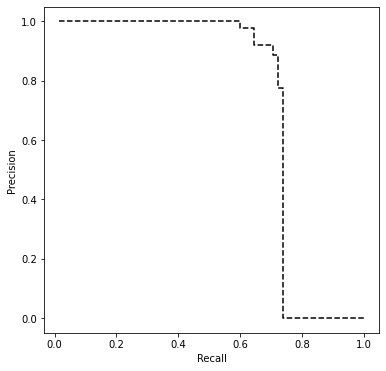

In [5]:
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(recall_scores, precision_scores, 'k--')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')


Text(0, 0.5, 'Precision')

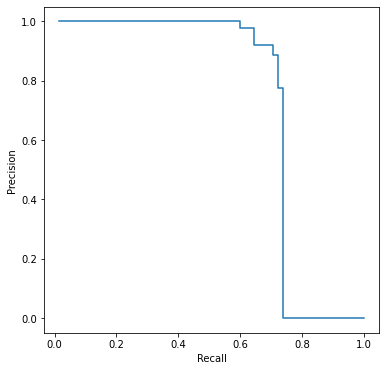

In [7]:
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(recall_scores, interpolated_precision_scores, '-')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
